In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.shape

(768, 9)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.size

6912

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

## remove duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

## remove missing

In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
df.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## remove outliers

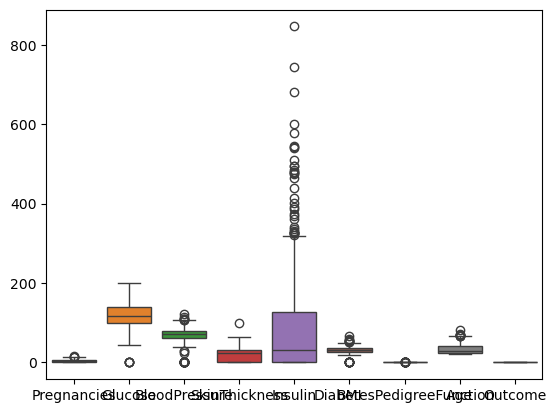

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [11]:
sns.boxplot(data=df)
plt.show()
plt.figure(figsize=(15,10))

In [12]:
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    upper_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x:lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']):
    outlier_capping(df,col)

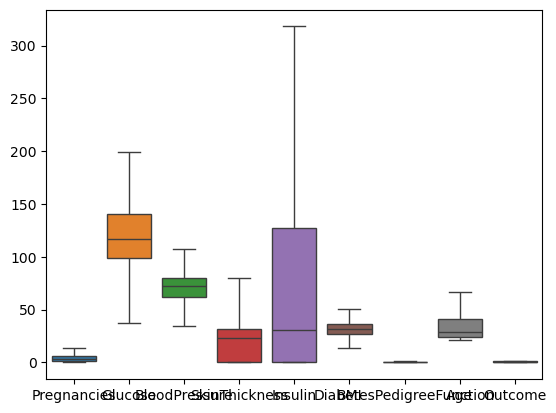

In [13]:
sns.boxplot(data=df)
plt.show()

## histogram

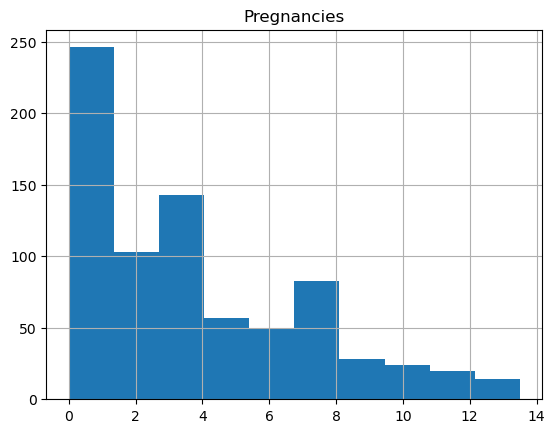

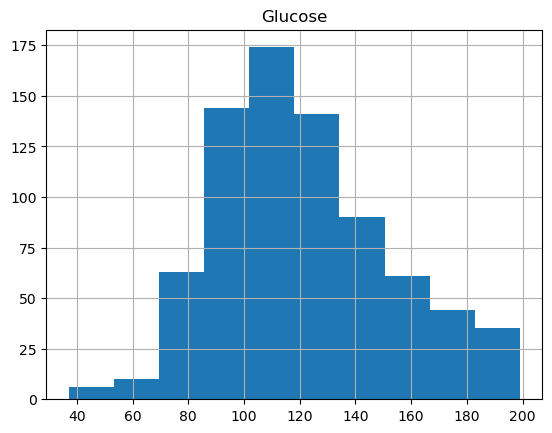

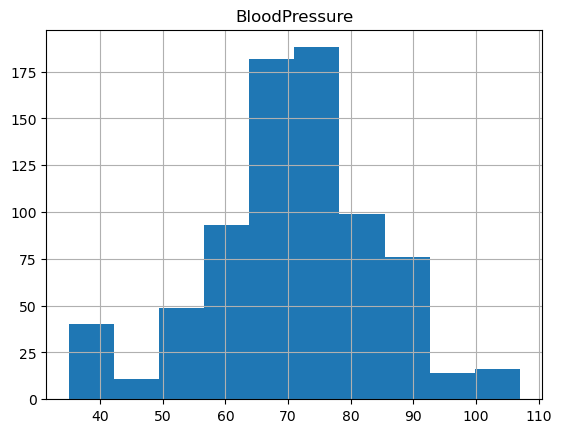

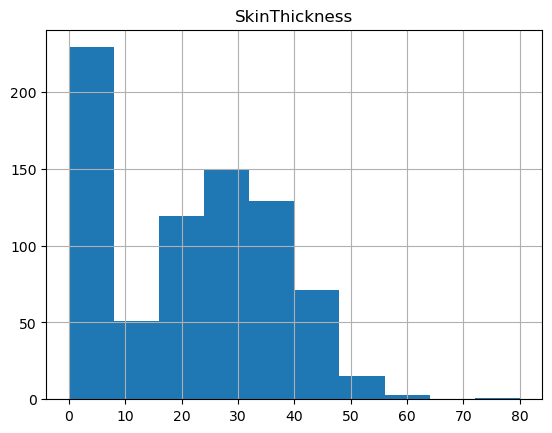

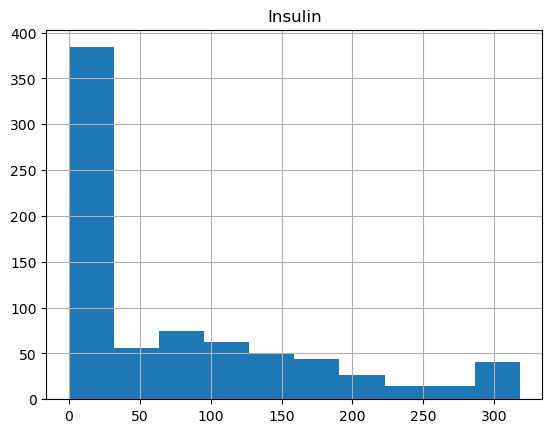

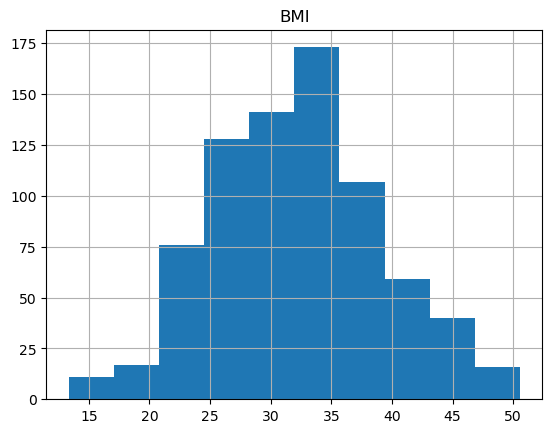

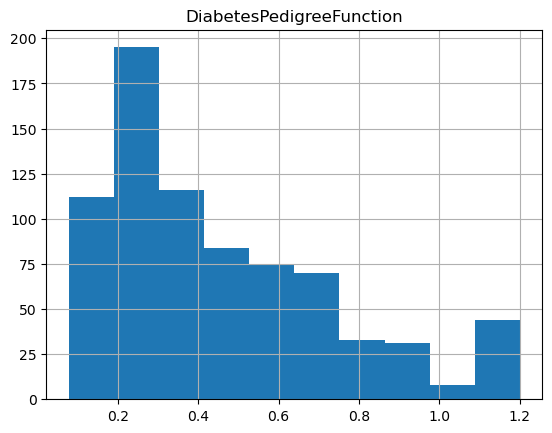

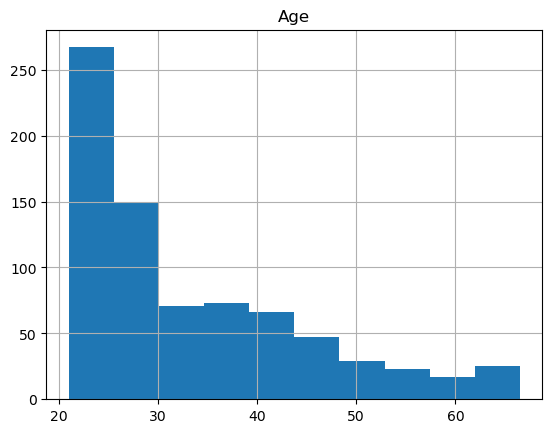

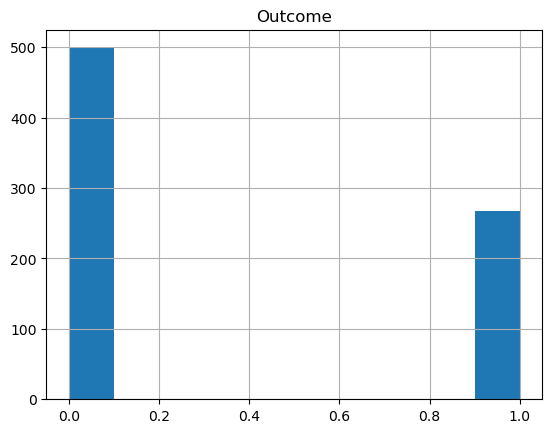

In [14]:
for col in df:
    df.hist(col)
    plt.show()

## correlation

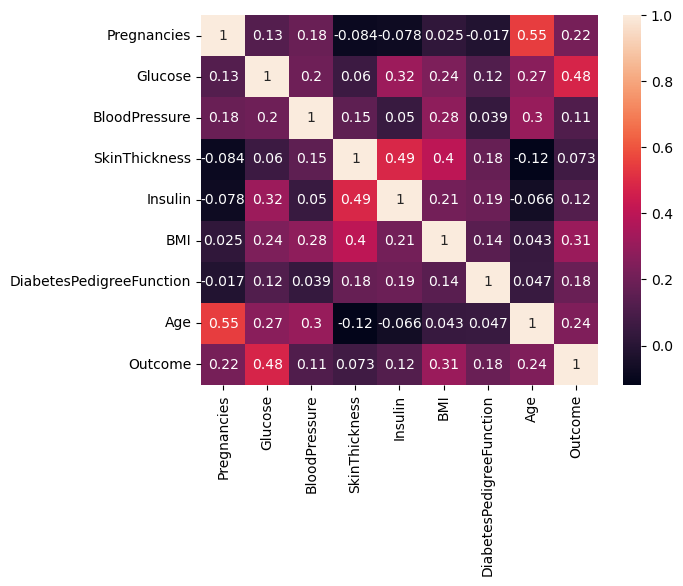

In [15]:
sns.heatmap(df.corr(),annot=True)
plt.show()

## pairplot

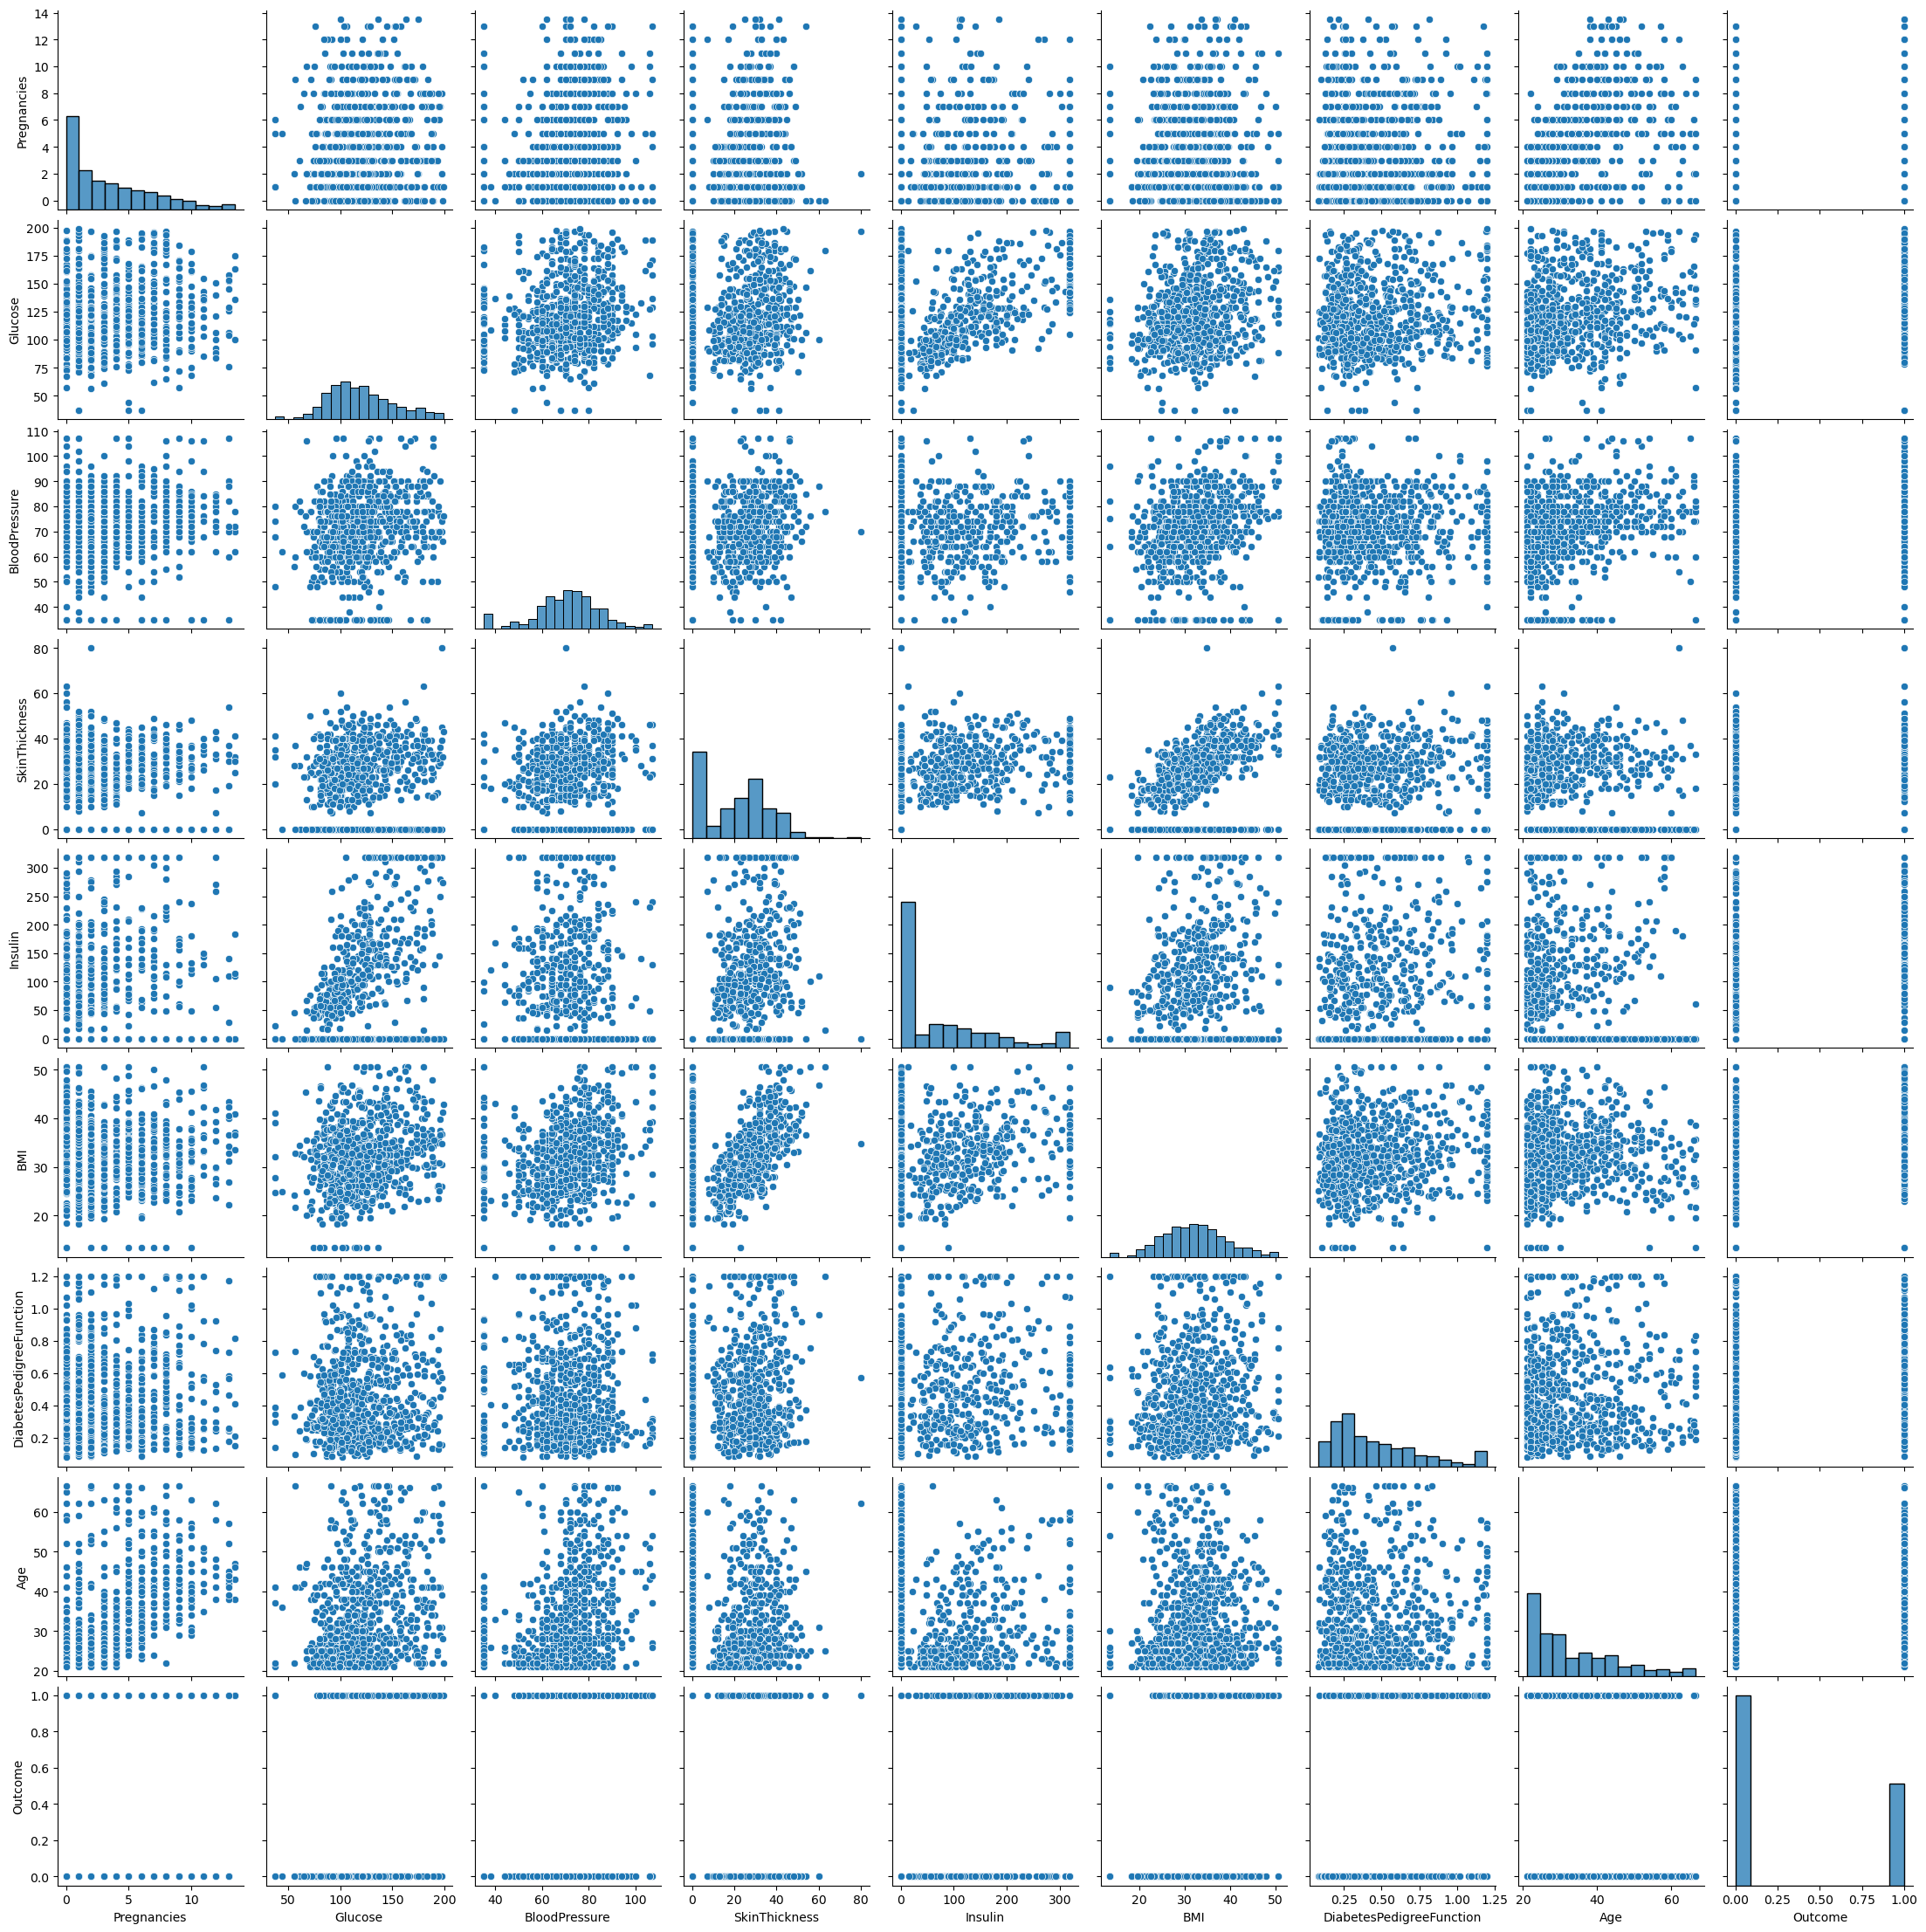

In [16]:
sns.pairplot(data=df)
plt.show()

In [17]:
cols = ['Glucose','BloodPressure','SkinThickness',
        'Insulin','BMI']

df[cols] = df[cols].replace(0, np.nan)

In [18]:
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

In [19]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [20]:
y=df[['Outcome']]
X=df.drop(columns=['Outcome'])

In [21]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0


## train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (614, 8)
X_test : (154, 8)


## scaling

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## model training and testing

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
y_pred=model.predict(X_test)
accuracy_score(y_test,y_pred)

0.7012987012987013

## sigmoid

In [26]:
sigmoid=model.predict_proba(X_test)[:,1]
sigmoid

array([0.59618358, 0.10486004, 0.30090834, 0.29047275, 0.00851379,
       0.1954409 , 0.44978085, 0.92232854, 0.08738011, 0.82193971,
       0.25857365, 0.54542616, 0.11579882, 0.12868223, 0.29395133,
       0.34049527, 0.68479569, 0.0869956 , 0.76878704, 0.17291839,
       0.15494415, 0.82300578, 0.17395358, 0.92354233, 0.53049957,
       0.01903982, 0.6568851 , 0.04501888, 0.32706533, 0.0379256 ,
       0.04254223, 0.0423611 , 0.44897634, 0.69450892, 0.86879387,
       0.13009855, 0.32697373, 0.06462045, 0.73255018, 0.59506295,
       0.30714941, 0.11133792, 0.1209285 , 0.28506991, 0.16011553,
       0.40620516, 0.14570326, 0.11003507, 0.68355522, 0.4129177 ,
       0.63325186, 0.77187213, 0.39441167, 0.06105761, 0.48097415,
       0.36923386, 0.76165805, 0.26571226, 0.73562616, 0.16830062,
       0.74166429, 0.24308688, 0.01261321, 0.87113385, 0.0391334 ,
       0.1494402 , 0.91088641, 0.02122833, 0.26813645, 0.65555634,
       0.18121721, 0.08642766, 0.31232011, 0.46128187, 0.03942

In [27]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve,roc_auc_score)

## precision score

In [28]:
precision=precision_score(y_test,y_pred)
precision

0.5869565217391305

## recall score

In [29]:
recall=recall_score(y_test,y_pred)
recall

0.5

## f1 score

In [30]:
f1=f1_score(y_test,y_pred)
f1

0.54

## classification report

In [31]:
classification=classification_report(y_test,y_pred)
classification

'              precision    recall  f1-score   support\n\n           0       0.75      0.81      0.78       100\n           1       0.59      0.50      0.54        54\n\n    accuracy                           0.70       154\n   macro avg       0.67      0.66      0.66       154\nweighted avg       0.69      0.70      0.70       154\n'

## confusion matrix

In [32]:
con_mat=confusion_matrix(y_test,y_pred)
con_mat

array([[81, 19],
       [27, 27]])

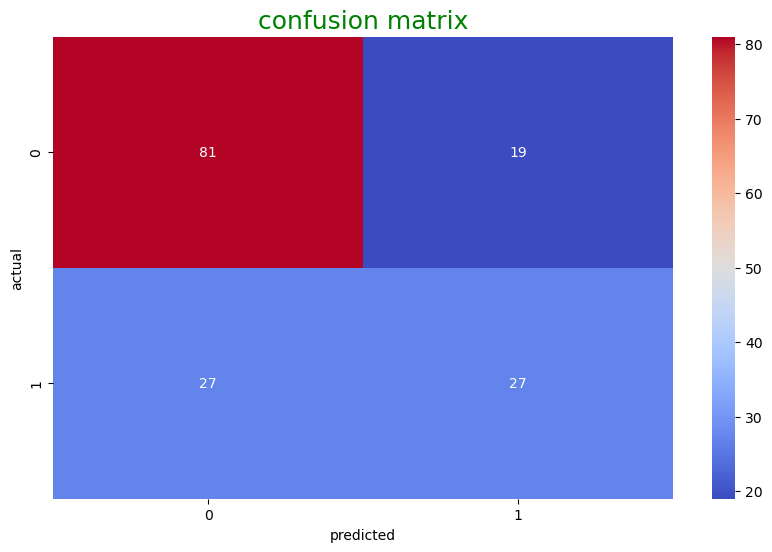

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(data=con_mat,annot=True,cmap='coolwarm')
plt.title('confusion matrix',color='green',size=18)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

## roc curve

In [34]:
auc_score=roc_auc_score(y_test,sigmoid)
auc_score

0.8216666666666668

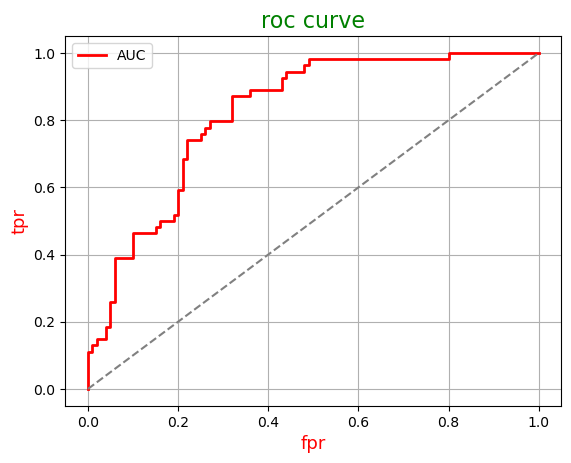

In [35]:
fpr,tpr,thersolds=roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,lw=2,color='red',label=f'AUC')
plt.plot([0,1],linestyle='--',color='grey')
plt.xlabel('fpr',color='red',size=13)
plt.ylabel('tpr',color='red',size=13)
plt.title('roc curve',color='green',size=16)
plt.grid()
plt.legend()
plt.show()

## coefficients

In [36]:
coef=pd.DataFrame({'features':X.columns,'coefficients':model.coef_[0]})
coef

,features,coefficients
0,Pregnancies,0.367228
1,Glucose,1.100528
2,BloodPressure,-0.147928
3,SkinThickness,0.054304
4,Insulin,0.015772
5,BMI,0.678341
6,DiabetesPedigreeFunction,0.282058
7,Age,0.198345


## deployment

In [37]:
import pickle

In [38]:
file='log16.pk1'
pickle.dump(model,open(file,'wb'))
file

'log16.pk1'

In [39]:
file1='std_sca.pk1'
pickle.dump(scaler,open(file1,'wb'))
file1

'std_sca.pk1'

## interview questions

### precision

### recall

Cross-Validation is a technique used to evaluate a machine learning model by dividing the dataset into multiple parts (folds) and training/testing the model multiple times.
better performance,reduces overfitting, uses dataefficently